In [1]:
import pandas as pd
import numpy as np
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
citibike = mglearn.datasets.load_citibike()

print("Citi Bike data:\n{}".format(citibike.head()))

Citi Bike data:
starttime
2015-08-01 00:00:00     3
2015-08-01 03:00:00     0
2015-08-01 06:00:00     9
2015-08-01 09:00:00    41
2015-08-01 12:00:00    39
Freq: 3h, Name: one, dtype: int64


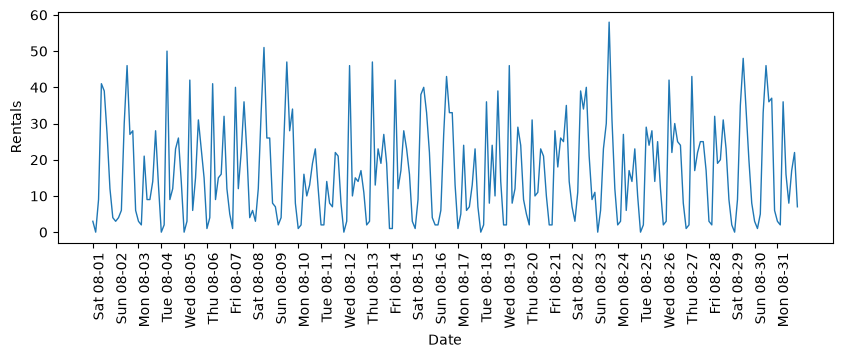

In [ ]:
#ありCiti Bikeステーションの自転車レンタル数

plt.figure(figsize=(10, 3))
xticks = pd.date_range(start=citibike.index.min(), end=citibike.index.max(),
                       freq='D')
plt.xticks(xticks, xticks.strftime("%a %m-%d"), rotation=90, ha="left")
plt.plot(citibike, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Rentals")
plt.show()

In [8]:
#ターゲット値（レンタル値）を抽出
y = citibike.values

#日時をPOSIX時間（秒）に変換し、特徴量Xとして使用
X = citibike.index.astype("int64").to_numpy().reshape(-1, 1) // 10 ** 9

In [6]:
#時系列データであるので、ある特定の日までの全てのデータを訓練セットとし、それ以降をテストセットとする
#最初の１８４データポイントを訓練に、残りをテストに使う

n_train = 184

#与えられた特徴量セットで回帰器を評価し、プロットする関数
def eval_on_features(features, target, regressor):
    X_train, X_test = features[:n_train], features[n_train:]

    y_train, y_test = target[:n_train], target[n_train:]
    regressor.fit(X_train, y_train)
    print("Test-set R^2: {:.2f}".format(regressor.score(X_test, y_test)))
    y_pred = regressor.predict(X_test)
    y_pred_train = regressor.predict(X_train)
    plt.figure(figsize=(10, 3))

    plt.xticks(range(0, len(X), 8), xticks.strftime("%a %m-%d"), rotation=90,
               ha="left")

    plt.plot(range(n_train), y_train, label="train")
    plt.plot(range(n_train, len(y_test) + n_train), y_test, '-', label="test")
    plt.plot(range(n_train), y_pred_train, '--', label="prediction train")

    plt.plot(range(n_train, len(y_test) + n_train), y_pred, '--',
             label="prediction test")
    plt.legend(loc=(1.01, 0))
    plt.xlabel("Date")
    plt.ylabel("Rentals")

Test-set R^2: -0.04


<Figure size 640x480 with 0 Axes>

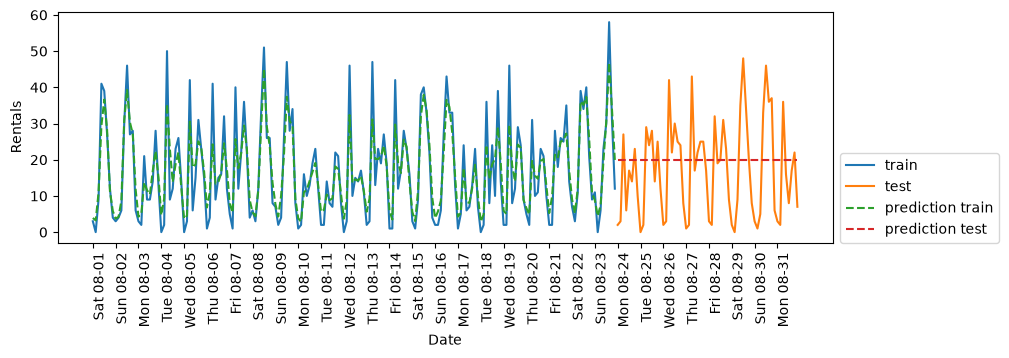

In [ ]:
#データの前処理をほどんど必要としないRandom Forest Regressorを使って、Citi Bikeのレンタル数を予測してみる
from sklearn.ensemble import RandomForestRegressor

#決定木は外挿が苦手なので、なにも学習できなかった
#訓練期間の日時は覚えられたけど、未来の日時に一般化できていない
regressor = RandomForestRegressor(n_estimators=100, random_state=0)
plt.figure()
eval_on_features(X, y, regressor)

Test-set R^2: 0.60


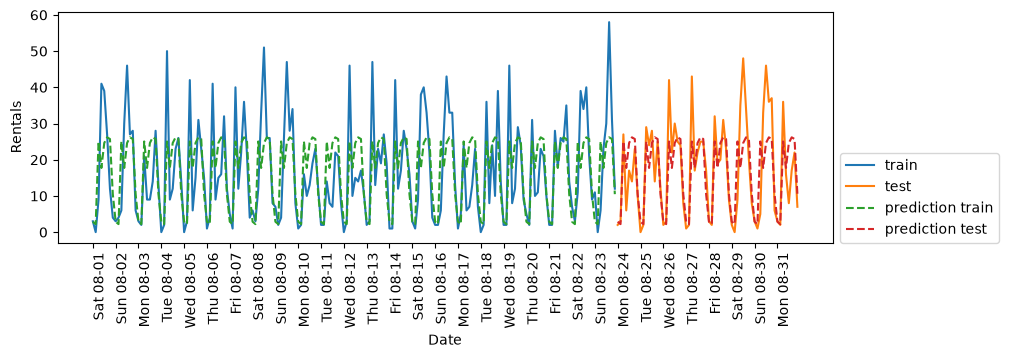

In [10]:
#重要そうな特徴量としてまず、１日の中の時刻を追加してみる
X_hour = citibike.index.hour.to_numpy().reshape(-1, 1)
eval_on_features(X_hour, y, regressor)

Test-set R^2: 0.84


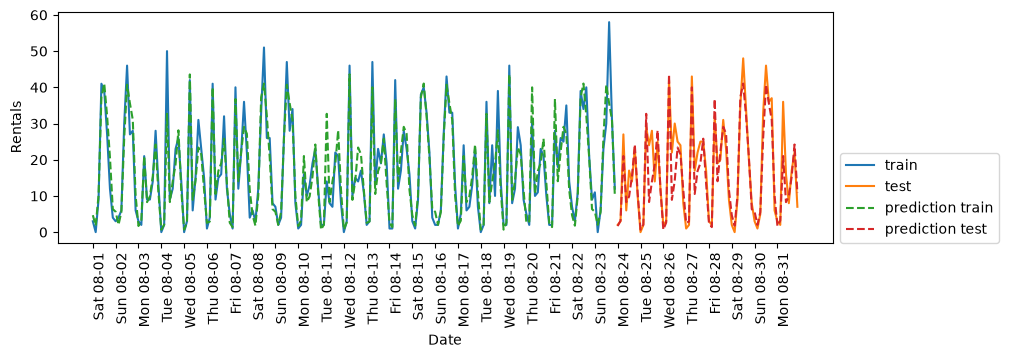

In [12]:
#上の予測は明らかに一週間周期のパターンを見落としている
#曜日情報を加えてみる

X_hour_week = np.hstack([X_hour, citibike.index.dayofweek.to_numpy().reshape(-1, 1)])
eval_on_features(X_hour_week, y, regressor)

Test-set R^2: 0.13


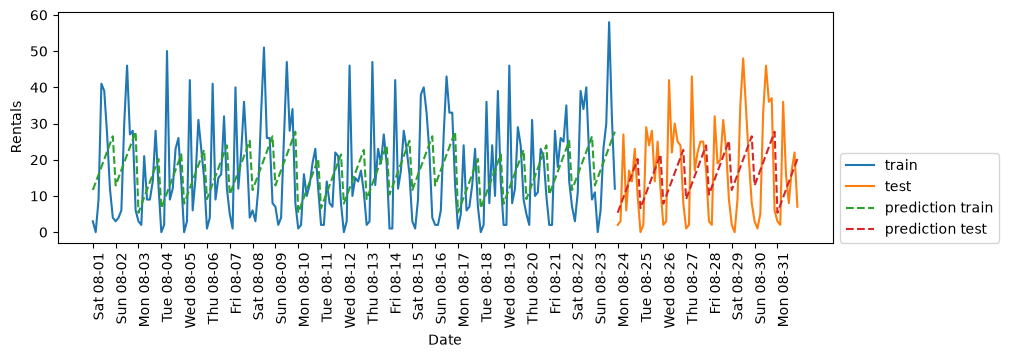

In [ ]:
#ランダムフォレストのような複雑なモデルは必要ないはず
#単純な線形モデルで十分かもしれない

from sklearn.linear_model import LinearRegression

#曜日や時刻が整数でエンコードされていて、連続値として解釈されてしまっている
eval_on_features(X_hour_week, y, LinearRegression())

Test-set R^2: 0.62


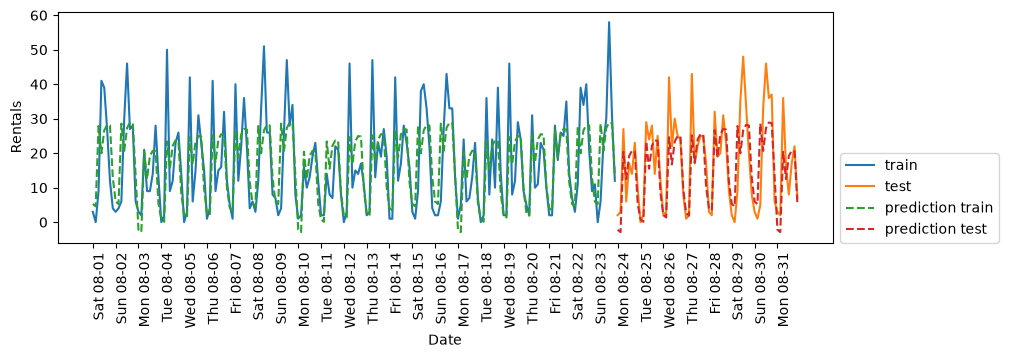

In [14]:
#One-hotエンコーディングを使って、曜日と時刻をカテゴリカルな特徴量として扱う
from sklearn.preprocessing import OneHotEncoder

X_hour_week_onehot = OneHotEncoder().fit_transform(X_hour_week).toarray()
eval_on_features(X_hour_week_onehot, y, LinearRegression())

Test-set R^2: 0.85


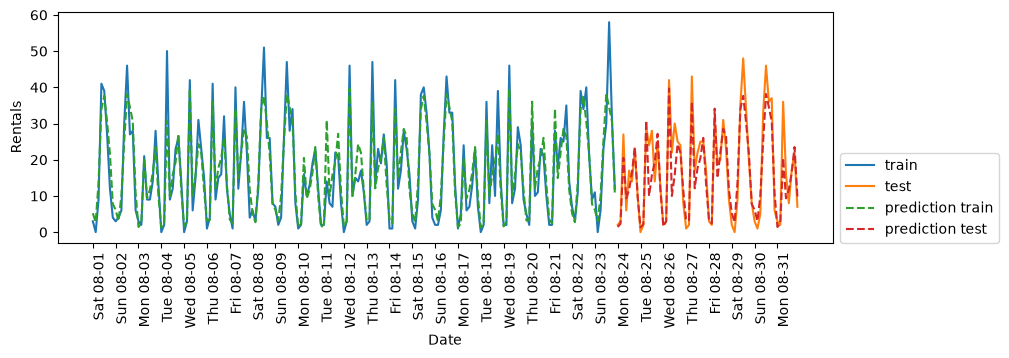

In [16]:
#線形モデルでは、曜日と時刻に対してそれぞれ係数を学習する
#つまり、時刻に対するパターンはすべての曜日に対して同じになる
#ここで交互作用特徴量を用いれば、曜日と時刻の組み合わせに対して係数を学習させることができる

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

#interaction_only=True なので、自分自身との掛け算 x_1^2,x_2^2 は作らない
poly_transformer = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_hour_week_onehot_poly = poly_transformer.fit_transform(X_hour_week_onehot)
lr = Ridge()
eval_on_features(X_hour_week_onehot_poly, y, lr)

In [ ]:
#このモデルで学習した係数をプロットしてみる
#これはランダムフォレストではできない

#時刻と曜日の特徴量に名前を付ける
hour = ["%02d:00" % i for i in range(0,24,3)]
weekday = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
features = weekday + hour

['Mon',
 'Tue',
 'Wed',
 'Thu',
 'Fri',
 'Sat',
 'Sun',
 '00:00',
 '03:00',
 '06:00',
 '09:00',
 '12:00',
 '15:00',
 '18:00',
 '21:00']

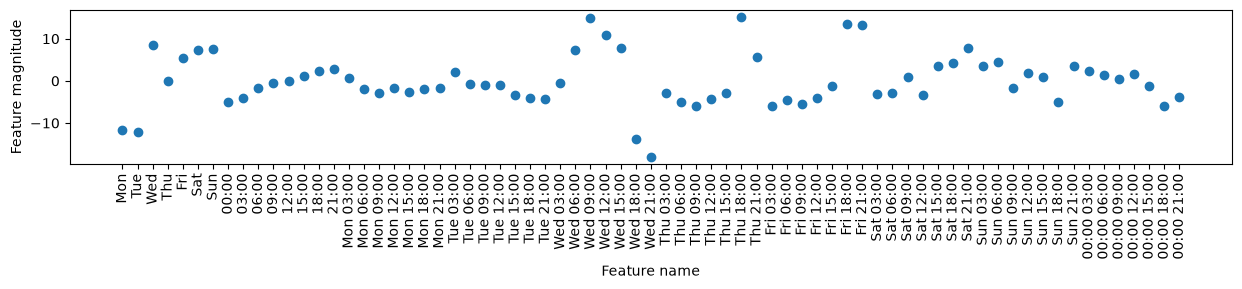

In [21]:
#交互作用特徴量に対して名前を付ける
#係数が非ゼロの特徴量だけを残す

features_poly = poly_transformer.get_feature_names_out(features)
features_nonzero = np.array(features_poly)[lr.coef_ != 0]
coef_nonzero = lr.coef_[lr.coef_ != 0]

plt.figure(figsize=(15, 2))
plt.plot(coef_nonzero, 'o')
plt.xticks(np.arange(len(coef_nonzero)), features_nonzero, rotation=90)
plt.xlabel("Feature name")
plt.ylabel("Feature magnitude")
plt.show()